# Figure generation experiments

**Author:** Jagruthi Nalajala  
**Paper:** *Quantifying the Revenue Degradation of Decoupled Recommendation and Promotion Systems: A Joint Causal Framework*

Run this notebook only after the three primary sweeps have written
`results_lambda.csv`, `results_beta.csv`, and `results_rho.csv`. It produces
the figures used in the manuscript. The Figure 4 bias result is an analytical
illustration; Figure 5 is an oracle structural illustration, not a learned
XGBoost result.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import os
import warnings
warnings.filterwarnings('ignore')

from scipy.special import softmax, expit

plt.rcParams.update({
    'font.family':      'serif',
    'font.size':        11,
    'axes.labelsize':   12,
    'axes.titlesize':   12,
    'legend.fontsize':  10,
    'figure.dpi':       150,
    'savefig.dpi':      300,
    'savefig.bbox':     'tight',
})

In [2]:
# Load CSV results
required = ['results_lambda.csv', 'results_beta.csv', 'results_rho.csv']
missing  = [f for f in required if not os.path.exists(f)]
if missing:
    raise FileNotFoundError(
        f'Missing result files: {missing}. '
        f'Run nalajala2026_simulation.ipynb first.')

df_lam  = pd.read_csv('results_lambda.csv')
df_beta = pd.read_csv('results_beta.csv')
df_rho  = pd.read_csv('results_rho.csv')

LAMBDA_GRID = sorted(df_lam['lambda'].unique())
BETA_GRID   = sorted(df_beta['beta'].unique())
RHO_GRID    = sorted(df_rho['rho'].unique())

print('Results loaded.')
print(f'Lambda values: {LAMBDA_GRID}')
print(f'Beta values:   {BETA_GRID}')
print(f'Rho values:    {RHO_GRID}')

Results loaded.
Lambda values: [np.float64(0.0), np.float64(0.25), np.float64(0.5), np.float64(0.75), np.float64(1.0)]
Beta values:   [np.float64(0.2), np.float64(0.4), np.float64(0.6), np.float64(0.8), np.float64(1.0)]
Rho values:    [np.float64(0.0), np.float64(0.25), np.float64(0.5), np.float64(0.75), np.float64(1.0)]


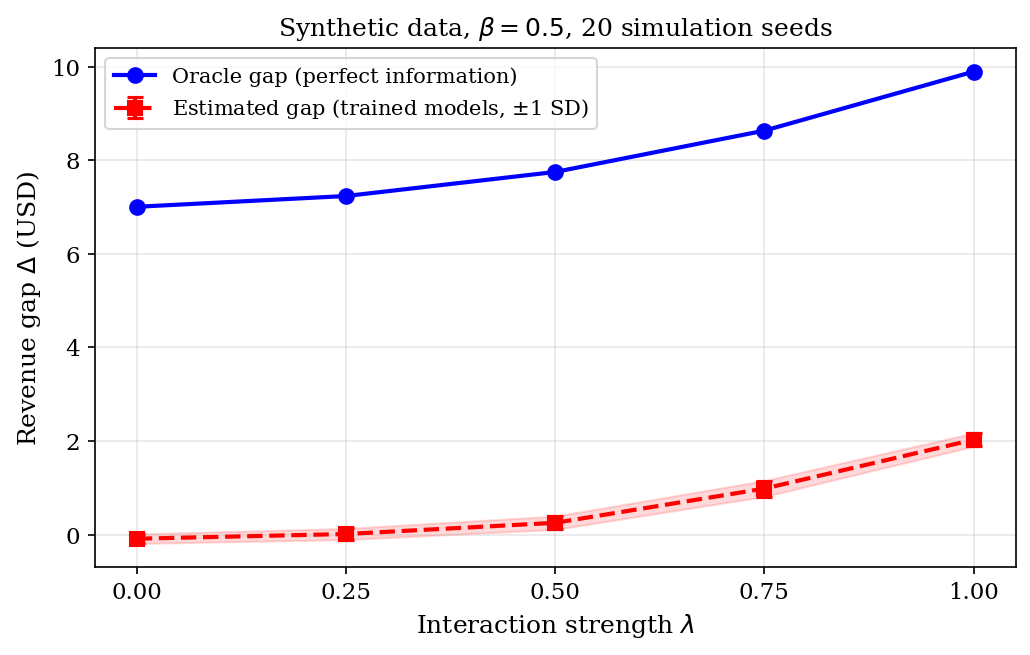

Figure 1 saved.


In [4]:
# =============================================================
# Figure 1: Revenue gap as a function of interaction strength (lambda)
# Corresponds to Table 2 and Section 6.1 of the paper.
# =============================================================

oracle_lam  = [df_lam[df_lam['lambda']==l].oracle_delta.mean() for l in LAMBDA_GRID]
est_lam     = [df_lam[df_lam['lambda']==l].est_delta.mean()    for l in LAMBDA_GRID]
sd_lam      = [df_lam[df_lam['lambda']==l].est_delta.std()     for l in LAMBDA_GRID]

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(LAMBDA_GRID, oracle_lam, 'b-o', linewidth=2, markersize=7,
        label='Oracle gap (perfect information)')
ax.errorbar(LAMBDA_GRID, est_lam, yerr=sd_lam,
            fmt='r--s', linewidth=2, markersize=7, capsize=4, capthick=1.5,
            label='Estimated gap (trained models, $\\pm$1 SD)')
ax.fill_between(LAMBDA_GRID,
                [e - s for e, s in zip(est_lam, sd_lam)],
                [e + s for e, s in zip(est_lam, sd_lam)],
                alpha=0.15, color='red')
ax.set_xlabel('Interaction strength $\\lambda$')
ax.set_ylabel('Revenue gap $\\Delta$ (USD)')
ax.set_title(f'Synthetic data, $\\beta=0.5$, {len(df_lam.seed.unique())} simulation seeds')
ax.legend(loc='upper left')
ax.grid(True, alpha=0.3)
ax.set_xticks(LAMBDA_GRID)
plt.tight_layout()
plt.savefig('figure2_gap_by_lambda.png')
plt.show()
print('Figure 1 saved.')

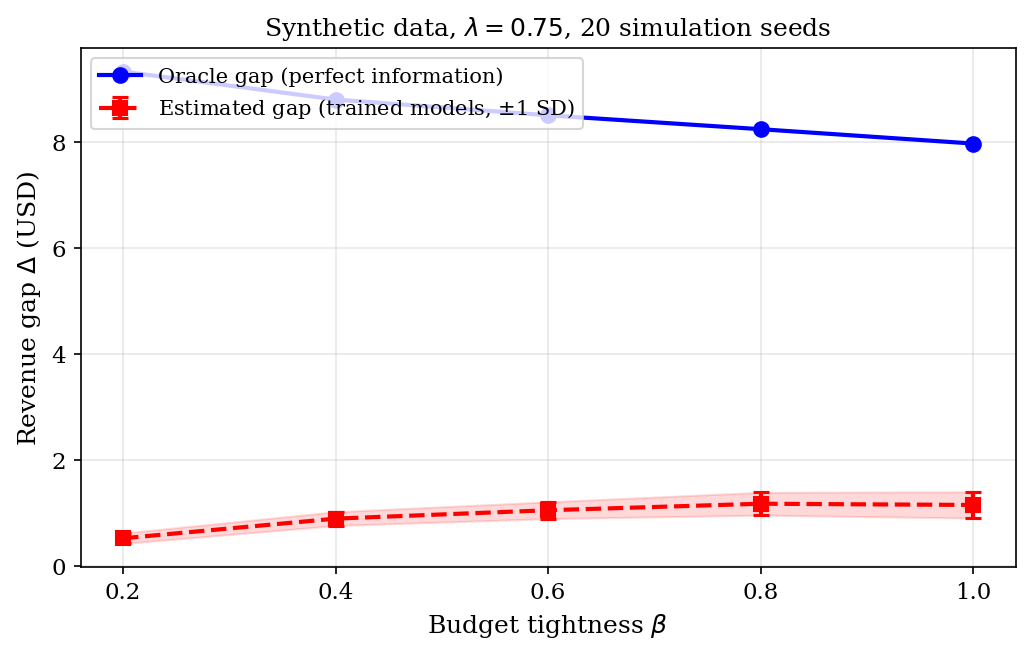

Figure 2 saved.


In [5]:
# =============================================================
# Figure 2: Revenue gap as a function of budget tightness (beta)
# Corresponds to Table 3 and Section 6.2 of the paper.
# =============================================================

oracle_beta = [df_beta[df_beta['beta']==b].oracle_delta.mean() for b in BETA_GRID]
est_beta    = [df_beta[df_beta['beta']==b].est_delta.mean()    for b in BETA_GRID]
sd_beta     = [df_beta[df_beta['beta']==b].est_delta.std()     for b in BETA_GRID]

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(BETA_GRID, oracle_beta, 'b-o', linewidth=2, markersize=7,
        label='Oracle gap (perfect information)')
ax.errorbar(BETA_GRID, est_beta, yerr=sd_beta,
            fmt='r--s', linewidth=2, markersize=7, capsize=4, capthick=1.5,
            label='Estimated gap (trained models, $\\pm$1 SD)')
ax.fill_between(BETA_GRID,
                [e - s for e, s in zip(est_beta, sd_beta)],
                [e + s for e, s in zip(est_beta, sd_beta)],
                alpha=0.15, color='red')
ax.set_xlabel('Budget tightness $\\beta$')
ax.set_ylabel('Revenue gap $\\Delta$ (USD)')
ax.set_title(f'Synthetic data, $\\lambda=0.75$, {len(df_beta.seed.unique())} simulation seeds')
ax.legend(loc='upper left')
ax.grid(True, alpha=0.3)
ax.set_xticks(BETA_GRID)
plt.tight_layout()
plt.savefig('figure4_gap_by_beta.png')
plt.show()
print('Figure 2 saved.')

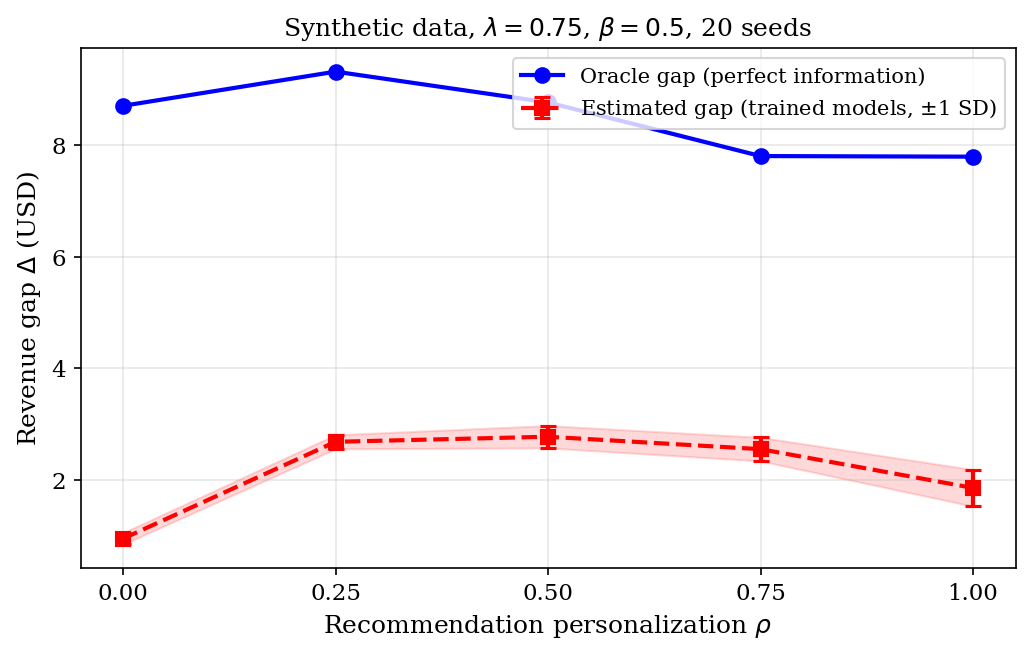

Figure 3 saved.


In [6]:
# =============================================================
# Figure 3: Revenue gap as a function of personalization level (rho)
# Corresponds to Table 4 and Section 6.3 of the paper.
# Both gaps are non-monotonic, peaking near rho=0.25, consistent
# with the entropy-based prediction of Section 4.2.
# =============================================================

oracle_rho  = [df_rho[df_rho['rho']==r].oracle_delta.mean() for r in RHO_GRID]
est_rho     = [df_rho[df_rho['rho']==r].est_delta.mean()    for r in RHO_GRID]
sd_rho      = [df_rho[df_rho['rho']==r].est_delta.std()     for r in RHO_GRID]

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(RHO_GRID, oracle_rho, 'b-o', linewidth=2, markersize=7,
        label='Oracle gap (perfect information)')
ax.errorbar(RHO_GRID, est_rho, yerr=sd_rho,
            fmt='r--s', linewidth=2, markersize=7, capsize=4, capthick=1.5,
            label='Estimated gap (trained models, $\\pm$1 SD)')
ax.fill_between(RHO_GRID,
                [e - s for e, s in zip(est_rho, sd_rho)],
                [e + s for e, s in zip(est_rho, sd_rho)],
                alpha=0.15, color='red')
ax.set_xlabel('Recommendation personalization $\\rho$')
ax.set_ylabel('Revenue gap $\\Delta$ (USD)')
ax.set_title(f'Synthetic data, $\\lambda=0.75$, $\\beta=0.5$, {len(df_rho.seed.unique())} seeds')
ax.legend(loc='upper right')
ax.grid(True, alpha=0.3)
ax.set_xticks(RHO_GRID)
plt.tight_layout()
plt.savefig('figure5_gap_by_rho.png')
plt.show()
print('Figure 3 saved.')

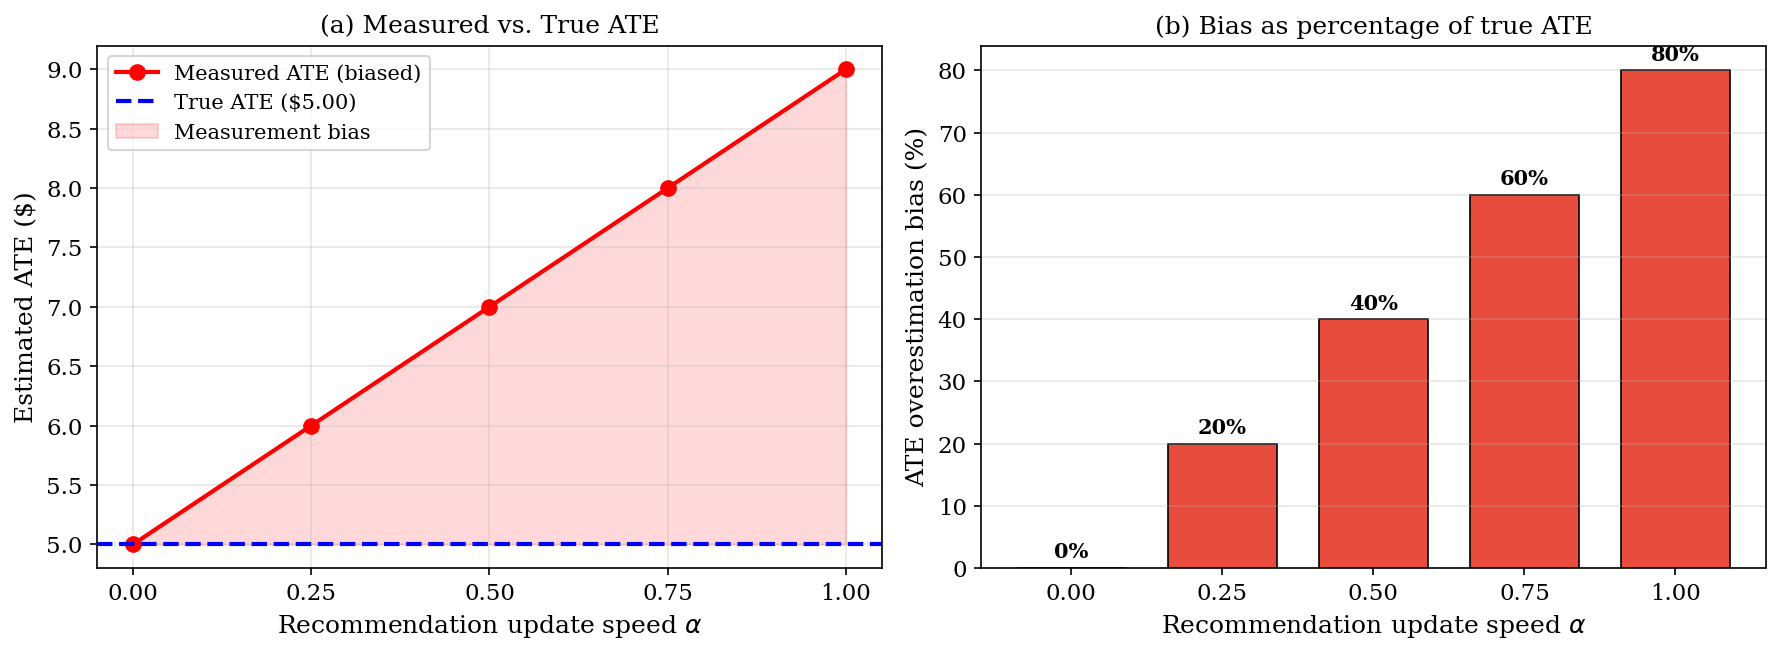

Figure 4 saved.


In [7]:
# =============================================================
# Figure 4: Adaptive recommendation-mediated bias
# Corresponds to Section 6.5 of the paper.
#
# This is an analytical illustration of Proposition 1, not a stochastic
# experiment. The displayed values are derived directly from the specified
# linear update model. Therefore, it has no simulated standard deviations or
# confidence intervals and should not be reported as repeated-trial evidence.
# =============================================================

UPDATE_SPEEDS = [0.0, 0.25, 0.50, 0.75, 1.0]
TRUE_ATE      = 5.0
# Analytical values from Proposition 1 linear update model.
# These reproduce the "Observed mean difference" column of Table 6.
MEASURED_ATES = [TRUE_ATE + alpha * 4.0 for alpha in UPDATE_SPEEDS]
BIAS_PCTS     = [(m - TRUE_ATE) / TRUE_ATE * 100 for m in MEASURED_ATES]

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

ax = axes[0]
ax.plot(UPDATE_SPEEDS, MEASURED_ATES, 'r-o', linewidth=2, markersize=7,
        label='Measured ATE (biased)')
ax.axhline(y=TRUE_ATE, color='blue', linewidth=2, linestyle='--',
           label=f'True ATE (${TRUE_ATE:.2f})')
ax.fill_between(UPDATE_SPEEDS, TRUE_ATE, MEASURED_ATES,
                alpha=0.15, color='red', label='Measurement bias')
ax.set_xlabel('Recommendation update speed $\\alpha$')
ax.set_ylabel('Estimated ATE (\$)')
ax.set_title('(a) Measured vs. True ATE')
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_xticks(UPDATE_SPEEDS)

ax = axes[1]
colors = ['#2ecc71' if b == 0 else '#e74c3c' for b in BIAS_PCTS]
bars   = ax.bar(UPDATE_SPEEDS, BIAS_PCTS, width=0.18,
                color=colors, edgecolor='black', linewidth=0.8)
for bar, pct in zip(bars, BIAS_PCTS):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 1,
            f'{pct:.0f}%', ha='center', va='bottom',
            fontsize=10, fontweight='bold')
ax.set_xlabel('Recommendation update speed $\\alpha$')
ax.set_ylabel('ATE overestimation bias (%)')
ax.set_title('(b) Bias as percentage of true ATE')
ax.grid(True, alpha=0.3, axis='y')
ax.set_xticks(UPDATE_SPEEDS)

plt.tight_layout()
plt.savefig('figure3_interference_bias.png')
plt.show()
print('Figure 4 saved.')

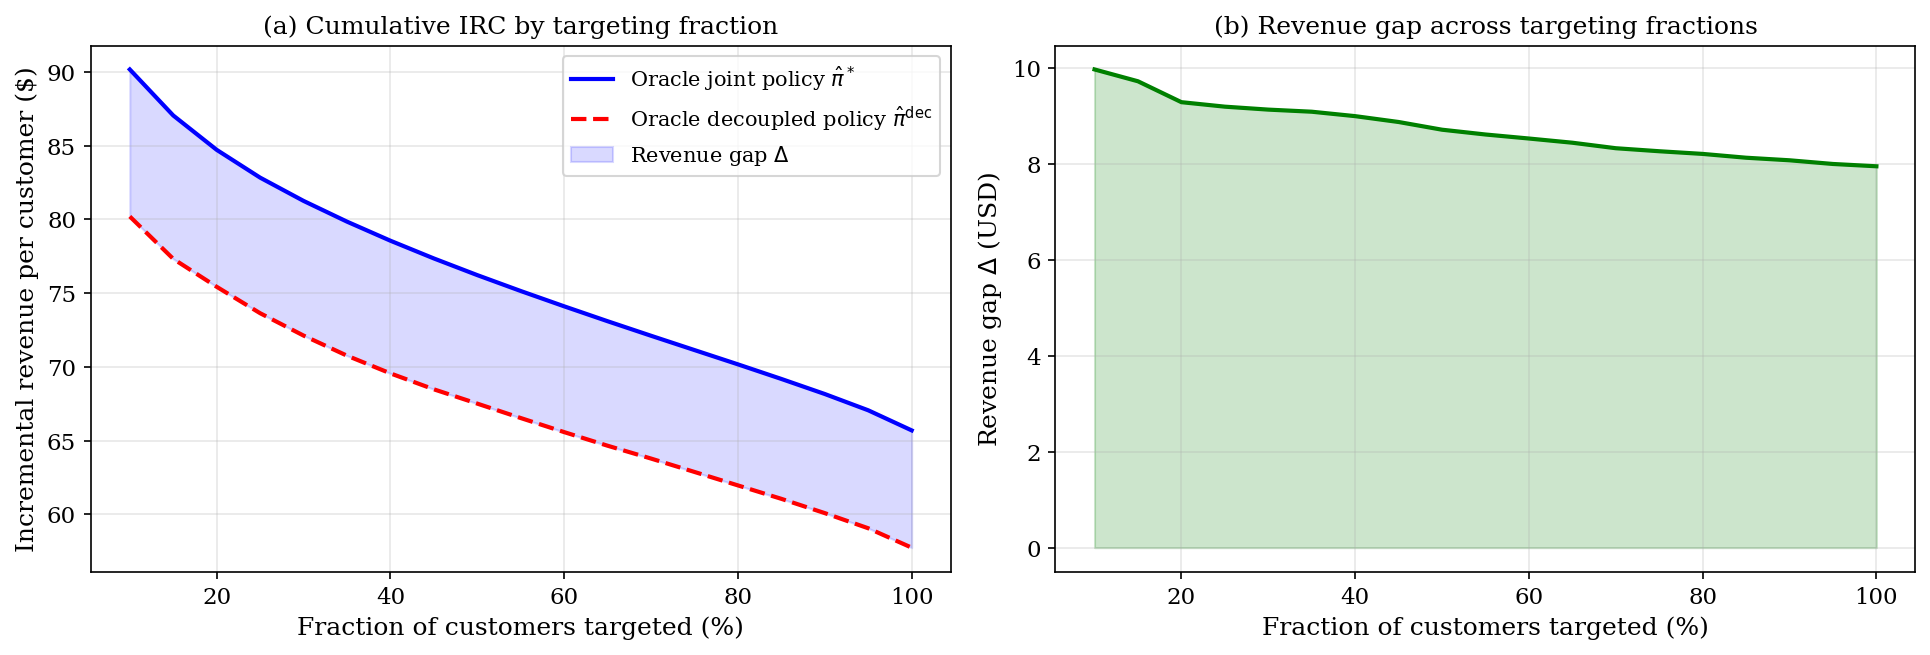

Figure 5 saved.


In [8]:
# =============================================================
# Figure 5: Cumulative IRC and revenue gap across targeting fractions
# Corresponds to Section 6.7 of the paper.
# Uses oracle policy at baseline conditions (lambda=0.75) to show
# that the joint advantage holds at every targeting threshold.
# Requires re-running the DGP (fast — one seed, oracle only, no training).
# =============================================================

# Re-initialize DGP with same seeds as simulation notebook
N_F, D_F, R_F, O_F = 10000, 10, 10, 3
DISCOUNT_F  = np.array([0.0, 0.10, 0.25])
SIGMA_FRAC_F = 0.15
LAMBDA_BASE  = 0.75

rng_f        = np.random.RandomState(0)
W_affinity_f = rng_f.randn(R_F, D_F) * 0.5
v_price_f    = rng_f.randn(D_F) * 0.5
W_baseline_f = rng_f.randn(R_F, D_F) * 0.3
b_baseline_f = rng_f.uniform(20, 80, size=R_F)

rng2_f       = np.random.RandomState(99)
W_coup_f     = rng2_f.randn(R_F, O_F)
W_coup_f    -= W_coup_f.mean(axis=1, keepdims=True)

rng_x_f = np.random.RandomState(42)
A_f     = rng_x_f.randn(D_F, D_F)
Sig_f   = A_f @ A_f.T / D_F + np.eye(D_F)
X_f     = rng_x_f.multivariate_normal(np.zeros(D_F), Sig_f, size=N_F)
X_f     = (X_f - X_f.mean(axis=0)) / X_f.std(axis=0)
AFF_f   = softmax(X_f @ W_affinity_f.T, axis=1)
PS_f    = expit(X_f @ v_price_f)
MU_f    = np.abs(X_f @ W_baseline_f.T + b_baseline_f) + 10
SIGMA_F = SIGMA_FRAC_F * MU_f.mean()

np.random.seed(0)
mu_mean_f = MU_f.mean(axis=1)
Y_f       = np.zeros((N_F, R_F, O_F))
for r in range(R_F):
    for o in range(O_F):
        base  = MU_f[:, r] + PS_f * DISCOUNT_F[o] * mu_mean_f
        gamma = AFF_f[:, r] * MU_f[:, r] * W_coup_f[r, o] * PS_f
        Y_f[:, r, o] = np.maximum(
            base + LAMBDA_BASE * gamma + np.random.normal(0, SIGMA_F, N_F), 0)

base_f   = Y_f[:, 0, 0]
incr_f   = Y_f - base_f[:, None, None]
flat_f   = incr_f.reshape(N_F, -1)
tau_r_f  = incr_f.mean(axis=2)
tau_o_f  = incr_f.mean(axis=1)

j_scores = flat_f.max(axis=1)
j_acts   = flat_f.argmax(axis=1)
d_scores = tau_r_f.max(axis=1) + tau_o_f.max(axis=1)
best_r_f = tau_r_f.argmax(axis=1)
best_o_f = tau_o_f.argmax(axis=1)

fracs    = np.linspace(0.1, 1.0, 19)
irc_j_f, irc_d_f = [], []
for frac in fracs:
    kf     = int(frac * N_F)
    top_j  = np.argsort(j_scores)[::-1][:kf]
    mask_j = np.zeros(N_F, bool); mask_j[top_j] = True
    irc_j_f.append(flat_f[np.arange(N_F), j_acts][mask_j].mean())

    top_d  = np.argsort(d_scores)[::-1][:kf]
    mask_d = np.zeros(N_F, bool); mask_d[top_d] = True
    irc_d_f.append(incr_f[np.arange(N_F), best_r_f, best_o_f][mask_d].mean())

gap_f  = [j - d for j, d in zip(irc_j_f, irc_d_f)]
pct_f  = [f * 100 for f in fracs]

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

ax = axes[0]
ax.plot(pct_f, irc_j_f, 'b-',  linewidth=2, label='Oracle joint policy $\\hat{\\pi}^*$')
ax.plot(pct_f, irc_d_f, 'r--', linewidth=2, label='Oracle decoupled policy $\\hat{\\pi}^{\\mathrm{dec}}$')
ax.fill_between(pct_f, irc_d_f, irc_j_f, alpha=0.15, color='blue',
                label='Revenue gap $\\Delta$')
ax.set_xlabel('Fraction of customers targeted (%)')
ax.set_ylabel('Incremental revenue per customer (\$)')
ax.set_title('(a) Cumulative IRC by targeting fraction')
ax.legend()
ax.grid(True, alpha=0.3)

ax = axes[1]
ax.plot(pct_f, gap_f, 'g-', linewidth=2)
ax.fill_between(pct_f, 0, gap_f, alpha=0.2, color='green')
ax.set_xlabel('Fraction of customers targeted (%)')
ax.set_ylabel('Revenue gap $\\Delta$ (USD)')
ax.set_title('(b) Revenue gap across targeting fractions')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('figure1_gap_curve.png')
plt.show()
print('Figure 5 saved.')

In [9]:
# Summary
figures = ['figure2_gap_by_lambda.png', 'figure4_gap_by_beta.png',
           'figure5_gap_by_rho.png',    'figure3_interference_bias.png',
           'figure1_gap_curve.png']
print('Figure generation complete.')
for f in figures:
    status = 'OK' if os.path.exists(f) else 'MISSING'
    print(f'  {f}: {status}')

Figure generation complete.
  figure2_gap_by_lambda.png: OK
  figure4_gap_by_beta.png: OK
  figure5_gap_by_rho.png: OK
  figure3_interference_bias.png: OK
  figure1_gap_curve.png: OK
